<a href="https://colab.research.google.com/github/areeba-munir/Image_Color_Palette_Generator/blob/main/image_color_palette_generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title
!mkdir -p static/uploads
!mkdir -p templates

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [ ]:
from scipy import datasets # contains an image of a racoon!
from PIL import Image # for reading image files

In [ ]:
# 1. Open your one single test image
file_name = '/content/test.jpg'
img = Image.open(file_name)
img = img.convert('RGB')

# 2. Turn it into a 3D array, then flatten it to a 2D list of pixels
img_array = np.array(img)
pixel_data = img_array.reshape(-1, 3)

# 3. Print the results to prove it works!
print("Success! I have loaded the image.")
print(f"There are {len(pixel_data)} total pixels in this image.")

Success! I have loaded the image.
There are 2157600 total pixels in this image.


In [ ]:
# 4. Find the unique colors and count how many times each one appears
# axis=0 tells NumPy to look at whole [R, G, B] rows, not individual numbers
unique_colors, counts = np.unique(pixel_data, axis=0, return_counts=True)

# 5. Sort the counts to find the most frequent ones
# np.argsort gives us the index numbers from smallest to largest
# We add [::-1] at the end to reverse it so the largest numbers are first
sorted_indexes = np.argsort(counts)[::-1]

# 6. Grab the top 10 colors and their counts using those sorted indexes
top_10_colors = unique_colors[sorted_indexes[:10]]
top_10_counts = counts[sorted_indexes[:10]]

# 7. Print the results!
print("\n--- Top 10 Most Common Colors (RGB) ---")
for i in range(10):
    print(f"Color {i+1}: RGB {top_10_colors[i]} - appeared {top_10_counts[i]} times")


--- Top 10 Most Common Colors (RGB) ---
Color 1: RGB [255 139   2] - appeared 4049 times
Color 2: RGB [254   0   0] - appeared 3870 times
Color 3: RGB [254 136   2] - appeared 2961 times
Color 4: RGB [255 137   1] - appeared 2864 times
Color 5: RGB [255 134   1] - appeared 2814 times
Color 6: RGB [255 216   1] - appeared 2384 times
Color 7: RGB [254 143   2] - appeared 2313 times
Color 8: RGB [255 151   2] - appeared 2115 times
Color 9: RGB [255 217   2] - appeared 1974 times
Color 10: RGB [254 138   1] - appeared 1960 times


In [ ]:
# Function to convert an RGB list into a HEX string
def rgb_to_hex(rgb):
    return "#{:02x}{:02x}{:02x}".format(rgb[0], rgb[1], rgb[2])

print("\n--- Top 10 HEX Codes ---")
for color in top_10_colors:
    print(rgb_to_hex(color))


--- Top 10 HEX Codes ---
#ff8b02
#fe0000
#fe8802
#ff8901
#ff8601
#ffd801
#fe8f02
#ff9702
#ffd902
#fe8a01


Loading and preprocessing image...
Running Machine Learning (K-Means)...

--- Professional Top 10 HEX Codes ---
#1771b9
#b1c264
#6aac0e
#9f0f4a
#ef8a05
#ee0b89
#ecca07
#0a4278
#e04107
#568cc4


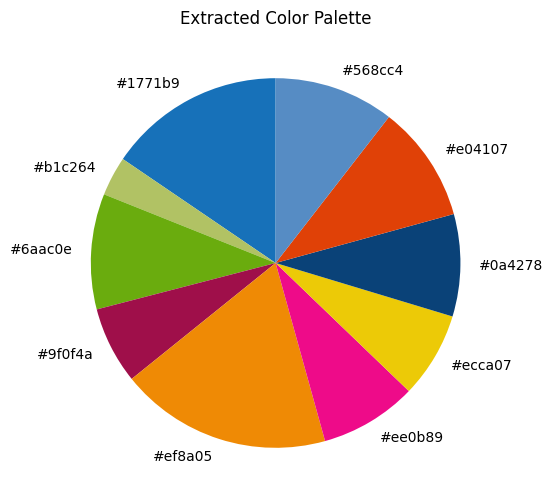

In [ ]:
import numpy as np
from PIL import Image
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# ==========================================
# 1. PREPROCESSING
# ==========================================
print("Loading and preprocessing image...")
img = Image.open('test.jpg').convert('RGB')
# Shrink the image drastically so the ML algorithm runs instantly
img = img.resize((200, 200))
img_array = np.array(img)
pixel_data = img_array.reshape(-1, 3)

# ==========================================
# 2. MODELING (Clustering)
# ==========================================
print("Running Machine Learning (K-Means)...")
# We want exactly 10 clusters (colors)
kmeans = KMeans(n_clusters=10, random_state=42)
kmeans.fit(pixel_data)

# The 'cluster_centers' are our 10 dominant RGB colors
colors = kmeans.cluster_centers_.astype(int)

# Count how many pixels were assigned to each of the 10 buckets
labels = kmeans.labels_
counts = np.bincount(labels)

# ==========================================
# 3. VISUALIZATION & OUTPUT
# ==========================================
def rgb_to_hex(rgb):
    return "#{:02x}{:02x}{:02x}".format(rgb[0], rgb[1], rgb[2])

hex_colors = [rgb_to_hex(color) for color in colors]

print("\n--- Professional Top 10 HEX Codes ---")
for hex_code in hex_colors:
    print(hex_code)

# Let's visualize the palette using a Pie Chart!
# Matplotlib needs colors to be between 0 and 1, so we divide by 255
plt.figure(figsize=(8, 6))
plt.pie(counts, labels=hex_colors, colors=colors/255, startangle=90)
plt.title("Extracted Color Palette")
plt.show()

# **The Frontend (HTML)**

In [ ]:
%%writefile templates/index.html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Pro Color Palette Generator</title>
    <style>
        body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; text-align: center; padding: 40px; background-color: #f4f4f9;}
        .form-container { background: white; padding: 20px; border-radius: 10px; display: inline-block; box-shadow: 0 4px 8px rgba(0,0,0,0.1); margin-bottom: 20px; }
        .controls { margin: 15px 0; }
        .color-box { width: 100px; height: 100px; display: inline-block; margin: 10px; border-radius: 10px; border: 1px solid #ccc; box-shadow: 2px 2px 5px rgba(0,0,0,0.1); cursor: pointer; transition: transform 0.2s;}
        .color-box:hover { transform: scale(1.1); }
        .hex-text { display: block; margin-top: 110px; font-weight: bold; }
        .palette-container { margin-top: 20px; }
        img { max-width: 400px; margin-top: 30px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0,0,0,0.2); }
        button { background-color: #4CAF50; color: white; padding: 10px 20px; border: none; border-radius: 5px; cursor: pointer; font-size: 16px; }
        button:hover { background-color: #45a049; }
    </style>
</head>
<body>

    <h1>Pro Image Color Palette Generator</h1>

    <div class="form-container">
        <form method="POST" action="/" enctype="multipart/form-data">
            <input type="file" name="file" accept="image/*" required><br>

            <div class="controls">
                <label for="num_colors">Palette Size:</label>
                <select name="num_colors" id="num_colors">
                    <option value="5">5 Colors</option>
                    <option value="10" selected>10 Colors</option>
                    <option value="15">15 Colors</option>
                </select>

                &nbsp;&nbsp;|&nbsp;&nbsp;

                <input type="checkbox" id="high_res" name="high_res" value="yes">
                <label for="high_res">High-Res Mode (Catches tiny details)</label>
            </div>

            <button type="submit">Generate Palette</button>
        </form>
    </div>

    {% if colors %}
        <h3>Click any color to copy the HEX code!</h3>
        <div class="palette-container">
            {% for color in colors %}
                <div class="color-box" style="background-color: {{ color }};" onclick="copyToClipboard('{{ color }}')">
                    <span class="hex-text">{{ color }}</span>
                </div>
            {% endfor %}
        </div>

        <img src="{{ image_path }}" alt="Uploaded Image">
    {% endif %}

    <script>
        function copyToClipboard(hexCode) {
            navigator.clipboard.writeText(hexCode).then(() => {
                alert("Copied " + hexCode + " to clipboard!");
            });
        }
    </script>
</body>
</html>

Overwriting templates/index.html


# **The Backend (Flask)**

In [ ]:
%%writefile app.py
import os
import numpy as np
from PIL import Image
from sklearn.cluster import KMeans
from flask import Flask, render_template, request
import logging

log = logging.getLogger('werkzeug')
log.setLevel(logging.ERROR)

app = Flask(__name__)
app.config['UPLOAD_FOLDER'] = 'static/uploads'

# Updated engine to accept dynamic color counts and resolution toggles
def get_dominant_colors(image_path, num_colors=10, high_res=False):
    img = Image.open(image_path).convert('RGB')

    # If High-Res is off, shrink heavily for speed.
    # If High-Res is on, keep it much larger to catch tiny details!
    if not high_res:
        img = img.resize((200, 200))
    else:
        img = img.resize((600, 600))

    img_array = np.array(img)
    pixel_data = img_array.reshape(-1, 3)

    # Use the user's chosen number of colors
    kmeans = KMeans(n_clusters=num_colors, random_state=42)
    kmeans.fit(pixel_data)
    colors = kmeans.cluster_centers_.astype(int)

    hex_colors = ["#{:02x}{:02x}{:02x}".format(c[0], c[1], c[2]) for c in colors]
    return hex_colors

@app.route('/', methods=['GET', 'POST'])
def home():
    if request.method == 'POST':
        file = request.files['file']

        # Grab the extra settings from the HTML form
        chosen_colors = int(request.form.get('num_colors', 10))
        is_high_res = request.form.get('high_res') == 'yes'

        if file:
            filepath = os.path.join(app.config['UPLOAD_FOLDER'], file.filename)
            file.save(filepath)

            # Pass settings to the engine
            extracted_colors = get_dominant_colors(filepath, num_colors=chosen_colors, high_res=is_high_res)

            return render_template('index.html', colors=extracted_colors, image_path=filepath)

    return render_template('index.html', colors=None)

if __name__ == '__main__':
    os.makedirs(app.config['UPLOAD_FOLDER'], exist_ok=True)
    app.run(port=5000)

Overwriting app.py


In [ ]:
from google.colab import output

print("\n" + "🚀 "*15)
print("CLICK THE LINK BELOW TO OPEN YOUR PRO WEBSITE:")
print(output.eval_js("google.colab.kernel.proxyPort(5000)"))
print("🚀 "*15 + "\n")

!python app.py


🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 
CLICK THE LINK BELOW TO OPEN YOUR PRO WEBSITE:
https://5000-m-s-kkb-usw3b0-ko5difh7j8n5-b.us-west3-0.prod.colab.dev
🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 

 * Serving Flask app 'app'
 * Debug mode: off
